In [1]:
import sys
import os
sys.path.append('../')

import pandas as pd
from util.polymarket_client import PolymarketAPIClient
from util.data_processor import parse_timestamp, TickDataIntervalEnum
from trading_rules.position_data import Positions
from trading_rules.mean_reversal import MeanReversal
from trading_rules.market_data import MarketData
from util.porfolio_performance import PortfolioPerformance
from util.backtester import perform_mean_reversal_backtest

In [2]:
MARKET_SLUG = 'will-jesus-christ-return-in-2025'

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly 
%matplotlib inline

In [4]:
client = PolymarketAPIClient()
market = client.get_price_history_by_outcome(MARKET_SLUG, desired_outcome="No", interval=TickDataIntervalEnum.FIVE_MINUTES)
market["symbol"] = MARKET_SLUG
market_data = MarketData(market)
positions = Positions(cash=10000.0)

resampled_df = market_data.df.resample("10min").last()
market_data.df = resampled_df

# Perform Mean Reversal
rule = MeanReversal(lookback_window=5, entry_z_threshold_entry=1.0, exit_z_threshold=0.5)
positions = perform_mean_reversal_backtest(symbol=MARKET_SLUG, rule=rule, market_data=market_data, positions=positions)
performance = PortfolioPerformance(positions=positions, initial_cash=10000, market_data=market_data)

Will Jesus Christ return in 2025?
Not Will Jesus Christ return in 2025?
requested start and end: 2024-12-31 12:00:00+00:00 2025-12-31 12:00:00+00:00


In [5]:
returns_df = performance.get_returns_history()

In [6]:
returns_df

,cash_balance,portfolio_value,total_value,simple_returns,log_returns
timestamp,,,,,
2025-03-20 22:10:00+00:00,10000.000,0.0,10000.000,0.0,NaN
2025-03-20 22:20:00+00:00,10000.000,0.0,10000.000,0.0,0.0
2025-03-20 22:30:00+00:00,10000.000,0.0,10000.000,0.0,0.0
2025-03-20 22:40:00+00:00,10000.000,0.0,10000.000,0.0,0.0
2025-03-20 22:50:00+00:00,10000.000,0.0,10000.000,0.0,0.0
...,...,...,...,...,...
2025-12-31 11:10:00+00:00,10576.777,0.0,10576.777,0.0,0.0
2025-12-31 11:20:00+00:00,10576.777,0.0,10576.777,0.0,0.0
2025-12-31 11:30:00+00:00,10576.777,0.0,10576.777,0.0,0.0


<Axes: xlabel='timestamp', ylabel='total_value'>

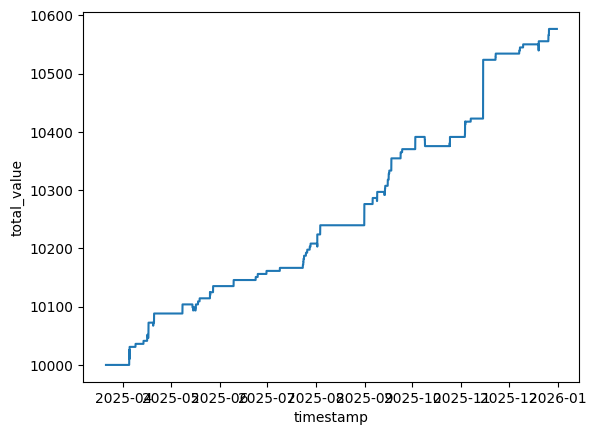

In [7]:
import seaborn as sns

sns.lineplot(returns_df, x=returns_df.index, y="total_value")

<Axes: xlabel='timestamp', ylabel='portfolio_value'>

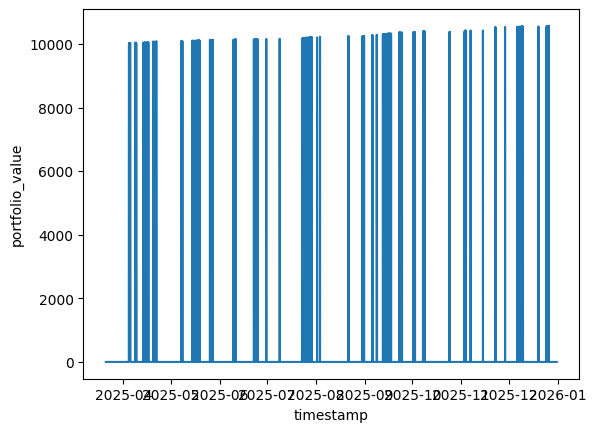

In [8]:
sns.lineplot(returns_df, x=returns_df.index, y="portfolio_value")

In [9]:
performance.get_annualized_sharpe_ratio()

0.32916054824276425